# 05 — Instrument-level analysis

**Child Mind Institute — Problematic Internet Use**

После общего анализа отдельных tabular features полезнее перейти к уровню **инструментов / обследований**.

Цели ноутбука:

- оценить полноту каждого instrument block;
- понять внутреннюю структуру и redundancy признаков;
- сравнить raw associations с `sii` и age-adjusted associations;
- отделить содержательно полезные блоки от эффектов возраста и missingness;
- сформировать решения для последующего preprocessing/modeling.



## 1. Imports and data loading

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency, pearsonr, rankdata, spearmanr

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

TARGET = "sii"
ID_COL = "id"
AGE_COL = "Basic_Demos-Age"
SEX_COL = "Basic_Demos-Sex"


In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
DATA_DICT_PATH = DATA_DIR / "data_dictionary.csv"

for path in [TRAIN_PATH, TEST_PATH, DATA_DICT_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path.resolve()}")

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
data_dict = pd.read_csv(DATA_DICT_PATH)

labeled = train.loc[train[TARGET].notna()].copy()

MODEL_FEATURES = [c for c in test.columns if c != ID_COL]

feature_meta = (
    data_dict.loc[data_dict["Field"].isin(MODEL_FEATURES)]
    .set_index("Field")
    .reindex(MODEL_FEATURES)
)

NUMERIC_COLS = [
    c for c in MODEL_FEATURES
    if feature_meta.loc[c, "Type"] in {"float", "int"}
]

CATEGORICAL_COLS = [
    c for c in MODEL_FEATURES
    if feature_meta.loc[c, "Type"] in {"categorical int", "str"}
]

print("Train:", train.shape)
print("Labeled subset:", labeled.shape)
print("Model features:", len(MODEL_FEATURES))


Train: (3960, 82)
Labeled subset: (2736, 82)
Model features: 58


## 2. Instrument map and coverage

In [3]:
instrument_features = {}

for instrument in feature_meta["Instrument"].dropna().unique():
    cols = [
        c for c in MODEL_FEATURES
        if feature_meta.loc[c, "Instrument"] == instrument
    ]
    instrument_features[instrument] = cols

for instrument, cols in instrument_features.items():
    print(f"\n{instrument} ({len(cols)} features)")
    print(cols)



Demographics (3 features)
['Basic_Demos-Enroll_Season', 'Basic_Demos-Age', 'Basic_Demos-Sex']

Children's Global Assessment Scale (2 features)
['CGAS-Season', 'CGAS-CGAS_Score']

Physical Measures (8 features)
['Physical-Season', 'Physical-BMI', 'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference', 'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP']

FitnessGram Vitals and Treadmill (4 features)
['Fitness_Endurance-Season', 'Fitness_Endurance-Max_Stage', 'Fitness_Endurance-Time_Mins', 'Fitness_Endurance-Time_Sec']

FitnessGram Child (15 features)
['FGC-Season', 'FGC-FGC_CU', 'FGC-FGC_CU_Zone', 'FGC-FGC_GSND', 'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone', 'FGC-FGC_PU', 'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR', 'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone']

Bio-electric Impedance Analysis (17 features)
['BIA-Season', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI', 'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BI

In [4]:
instrument_rows = []

for instrument, cols in instrument_features.items():
    block = train[cols]

    instrument_rows.append({
        "instrument": instrument,
        "n_features": len(cols),
        "participants_any_data_%": (
            block.notna().any(axis=1).mean() * 100
        ),
        "participants_complete_data_%": (
            block.notna().all(axis=1).mean() * 100
        ),
        "mean_feature_missing_%": (
            block.isna().mean().mean() * 100
        ),
    })

instrument_coverage = (
    pd.DataFrame(instrument_rows)
    .sort_values("participants_any_data_%", ascending=False)
    .reset_index(drop=True)
)

display(instrument_coverage.round(2))


,instrument,n_features,participants_any_data_%,participants_complete_data_%,mean_feature_missing_%
0,Demographics,3,100.00,100.00,0.00
1,Internet Use,2,89.39,83.36,13.62
2,FitnessGram Child,15,84.49,25.98,48.55
3,Physical Measures,8,83.59,21.77,29.90
4,Sleep Disturbance Scale,3,66.11,65.81,34.07
5,Children's Global Assessment Scale,2,64.52,61.14,37.17
6,Bio-electric Impedance Analysis,17,54.17,50.28,49.49
7,Physical Activity Questionnaire (Children),2,43.46,43.46,56.54
8,FitnessGram Vitals and Treadmill,4,33.03,18.66,77.71
9,Physical Activity Questionnaire (Adolescents),2,11.99,11.99,88.01


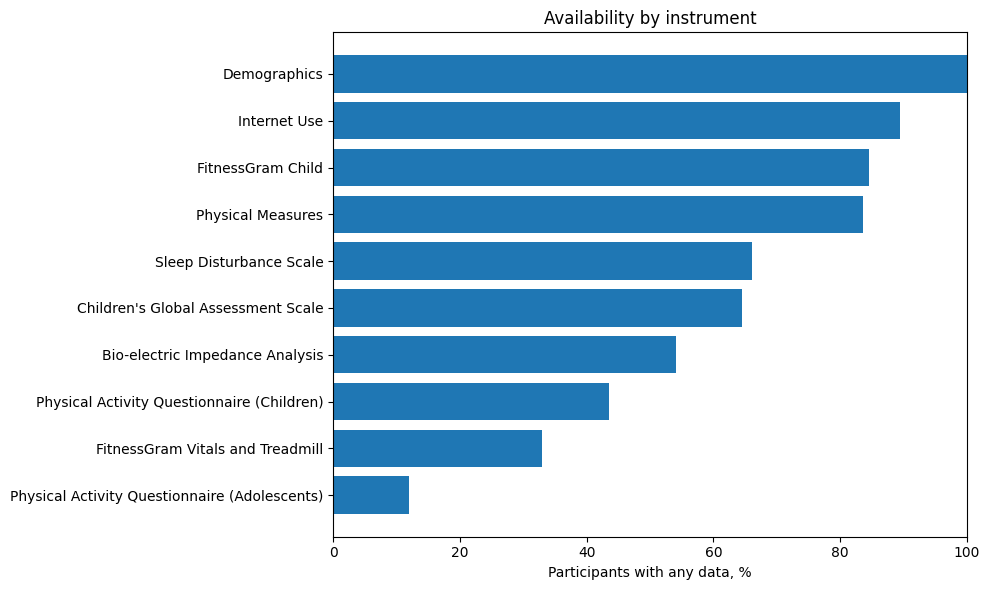

In [5]:
coverage_plot = (
    instrument_coverage
    .set_index("instrument")["participants_any_data_%"]
    .sort_values()
)

plt.figure(figsize=(10, 6))
plt.barh(coverage_plot.index, coverage_plot.values)
plt.xlabel("Participants with any data, %")
plt.ylabel("")
plt.title("Availability by instrument")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()


## 3. Helper functions

Для каждого содержательного блока будем использовать одинаковые меры:

- **raw Spearman** — ordinal association numeric feature ↔ `sii`;
- **partial Spearman controlling for age** — та же связь после удаления рангового эффекта возраста;
- **Cramér's V** — связь categorical feature ↔ `sii`;
- availability by age — чтобы отличать обычные NaN от структурных пропусков.


In [6]:
def partial_spearman_age(df, feature, target=TARGET, age=AGE_COL):
    sub = df[[feature, target, age]].dropna()

    if (
        len(sub) < 10
        or sub[feature].nunique() < 2
        or sub[age].nunique() < 2
    ):
        return np.nan, np.nan, len(sub)

    x_rank = rankdata(sub[feature].to_numpy())
    y_rank = rankdata(sub[target].to_numpy())
    age_rank = rankdata(sub[age].to_numpy())

    X = np.column_stack([np.ones(len(sub)), age_rank])

    beta_x = np.linalg.lstsq(X, x_rank, rcond=None)[0]
    beta_y = np.linalg.lstsq(X, y_rank, rcond=None)[0]

    residual_x = x_rank - X @ beta_x
    residual_y = y_rank - X @ beta_y

    r, p = pearsonr(residual_x, residual_y)

    return r, p, len(sub)


def numeric_association_table(df, cols):
    rows = []

    for col in cols:
        if col not in NUMERIC_COLS:
            continue

        sub = df[[col, TARGET]].dropna()

        if len(sub) < 10 or sub[col].nunique() < 2:
            continue

        raw_rho, raw_p = spearmanr(sub[col], sub[TARGET])

        if col == AGE_COL:
            partial_rho, partial_p, partial_n = np.nan, np.nan, len(sub)
        else:
            partial_rho, partial_p, partial_n = partial_spearman_age(
                df, col
            )

        rows.append({
            "feature": col,
            "n": len(sub),
            "raw_rho": raw_rho,
            "raw_p": raw_p,
            "partial_rho_age": partial_rho,
            "partial_p_age": partial_p,
            "abs_partial_rho": abs(partial_rho)
            if not np.isnan(partial_rho) else np.nan,
        })

    if not rows:
        return pd.DataFrame()

    return (
        pd.DataFrame(rows)
        .sort_values(
            "abs_partial_rho",
            ascending=False,
            na_position="last",
        )
        .reset_index(drop=True)
    )


def cramers_v(x, y):
    table = pd.crosstab(x, y)

    if min(table.shape) < 2:
        return np.nan

    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()

    phi2 = chi2 / n
    r, k = table.shape

    phi2_corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / max(n - 1, 1),
    )

    r_corr = r - ((r - 1) ** 2) / max(n - 1, 1)
    k_corr = k - ((k - 1) ** 2) / max(n - 1, 1)

    denom = min(k_corr - 1, r_corr - 1)

    if denom <= 0:
        return np.nan

    return np.sqrt(phi2_corr / denom)


def categorical_association_table(df, cols):
    rows = []

    for col in cols:
        if col not in CATEGORICAL_COLS:
            continue

        x = (
            df[col]
            .astype("object")
            .where(df[col].notna(), "__MISSING__")
            .astype(str)
        )

        rows.append({
            "feature": col,
            "n_categories_including_missing": x.nunique(),
            "missing_%": df[col].isna().mean() * 100,
            "cramers_v": cramers_v(
                x,
                df[TARGET].astype(int),
            ),
        })

    if not rows:
        return pd.DataFrame()

    return (
        pd.DataFrame(rows)
        .sort_values("cramers_v", ascending=False)
        .reset_index(drop=True)
    )


def plot_numeric_by_sii(df, feature):
    groups = []
    labels = []

    for cls in sorted(df[TARGET].dropna().astype(int).unique()):
        values = df.loc[df[TARGET].eq(cls), feature].dropna()

        if len(values) == 0:
            continue

        groups.append(values)
        labels.append(f"{cls}\n(n={len(values)})")

    if not groups:
        return

    plt.figure(figsize=(8, 4))
    plt.boxplot(groups, labels=labels, showfliers=False)
    plt.xlabel("SII")
    plt.ylabel(feature)
    plt.title(f"{feature} by SII")
    plt.tight_layout()
    plt.show()


def plot_availability_by_age(df, cols, title):
    availability = pd.DataFrame({
        col: df.groupby(AGE_COL)[col].apply(
            lambda x: x.notna().mean()
        )
        for col in cols
    })

    plt.figure(figsize=(10, 5))

    for col in availability.columns:
        plt.plot(
            availability.index,
            availability[col],
            marker="o",
            label=col,
        )

    plt.xlabel("Age")
    plt.ylabel("Fraction available")
    plt.title(title)
    plt.ylim(-0.05, 1.05)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return availability


## 4. Demographics

Demographics содержит:

- enrollment season;
- age;
- sex.

Из предыдущего EDA известно, что **age существенно связан с `sii`**, поэтому дальше он используется как основной confounder при интерпретации физических и физиологических признаков.


In [7]:
DEMOGRAPHICS = instrument_features.get("Demographics", [])

display(
    numeric_association_table(
        labeled,
        DEMOGRAPHICS,
    ).round(4)
)

display(
    categorical_association_table(
        labeled,
        DEMOGRAPHICS,
    ).round(4)
)


,feature,n,raw_rho,raw_p,partial_rho_age,partial_p_age,abs_partial_rho
0,Basic_Demos-Age,2736,0.3787,0.0,NaN,NaN,NaN


,feature,n_categories_including_missing,missing_%,cramers_v
0,Basic_Demos-Sex,2,0.0,0.0948
1,Basic_Demos-Enroll_Season,4,0.0,0.0110


,count,mean,median,std
sii,,,,
0.0,1594,9.25,9.0,3.13
1.0,730,11.12,11.0,3.30
2.0,378,12.29,12.0,3.28
3.0,34,14.68,14.0,2.38


C:\Users\HP\AppData\Local\Temp\ipykernel_10576\1694861711.py:153: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


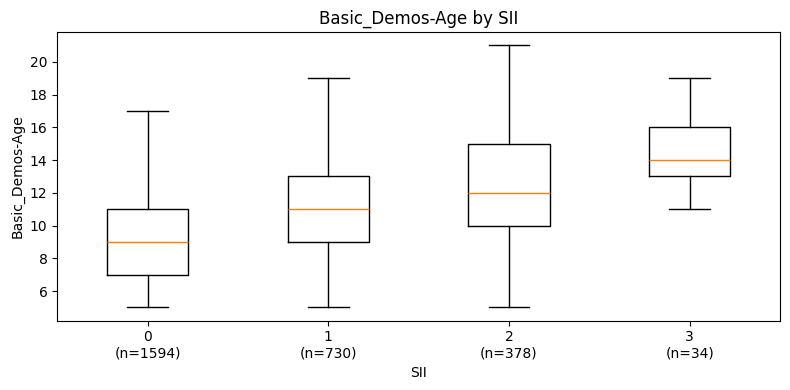

In [8]:
age_by_sii = (
    labeled.groupby(TARGET)[AGE_COL]
    .agg(["count", "mean", "median", "std"])
)

display(age_by_sii.round(2))
plot_numeric_by_sii(labeled, AGE_COL)


### Interpretation

Age — один из наиболее сильных univariate correlates of `sii` в tabular dataset. Поэтому raw associations, особенно для body size, strength и body composition, нельзя интерпретировать без age adjustment.

Sex показывает более слабую categorical association, а enrollment season практически не несёт самостоятельной информации на уровне простого univariate screening.


## 5. Children's Global Assessment Scale (CGAS)

CGAS представлен одним основным score и season.

Основной вопрос: отражает ли общий уровень функционирования заметную связь с `sii`.


,feature,n,raw_rho,raw_p,partial_rho_age,partial_p_age,abs_partial_rho
0,CGAS-CGAS_Score,2342,-0.073,0.0004,-0.0762,0.0002,0.0762


,feature,n_categories_including_missing,missing_%,cramers_v
0,CGAS-Season,5,14.4006,0.0


C:\Users\HP\AppData\Local\Temp\ipykernel_10576\1694861711.py:153: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


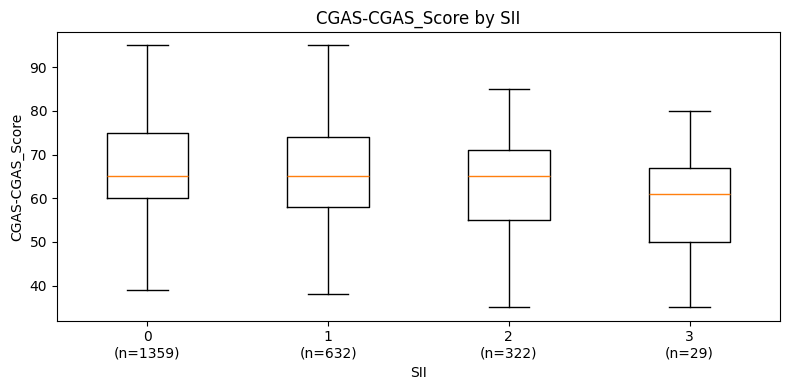

In [9]:
CGAS = instrument_features.get(
    "Children's Global Assessment Scale",
    [],
)

cgas_numeric = numeric_association_table(labeled, CGAS)
cgas_categorical = categorical_association_table(labeled, CGAS)

display(cgas_numeric.round(4))
display(cgas_categorical.round(4))

plot_numeric_by_sii(labeled, "CGAS-CGAS_Score")


### Interpretation

`CGAS-CGAS_Score` имеет слабую отрицательную association с `sii` (около −0.07), которая практически не меняется после контроля возраста.

То есть более высокий `sii` связан с немного более низким CGAS score, но эффект невелик.


## 6. Physical Measures

В блок входят BMI, height, weight, waist circumference, blood pressure и heart rate.

Здесь особенно важно сравнить raw и age-adjusted associations.


In [10]:
PHYSICAL = instrument_features.get("Physical Measures", [])

physical_assoc = numeric_association_table(
    labeled,
    PHYSICAL,
)

display(physical_assoc.round(4))


,feature,n,raw_rho,raw_p,partial_rho_age,partial_p_age,abs_partial_rho
0,Physical-Height,2530,0.3775,0.0000,0.0842,0.0000,0.0842
1,Physical-Weight,2572,0.3496,0.0000,0.0752,0.0001,0.0752
2,Physical-HeartRate,2486,-0.0232,0.2477,0.0620,0.0020,0.0620
3,Physical-BMI,2527,0.2373,0.0000,0.0472,0.0177,0.0472
4,Physical-Systolic_BP,2478,0.1461,0.0000,0.0400,0.0467,0.0400
5,Physical-Waist_Circumference,483,0.2953,0.0000,0.0341,0.4545,0.0341
6,Physical-Diastolic_BP,2478,0.0612,0.0023,0.0123,0.5400,0.0123


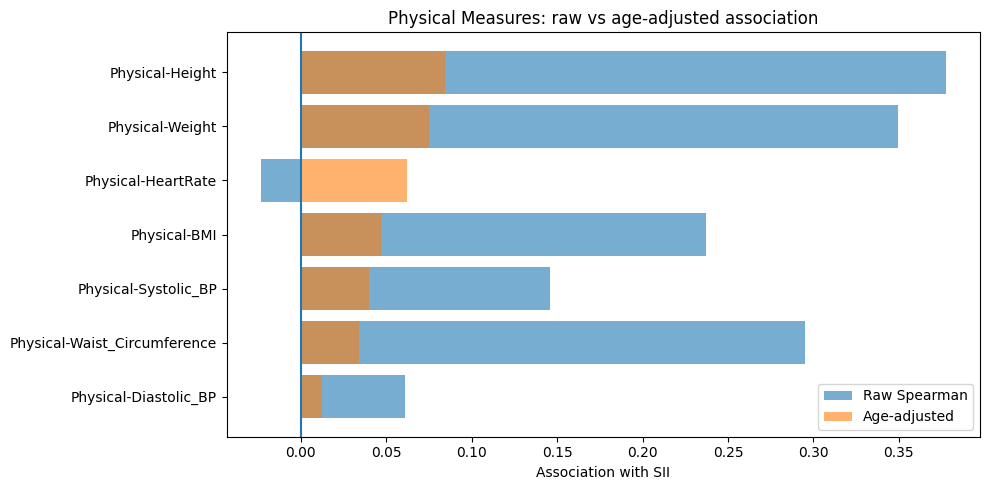

In [11]:
physical_plot = (
    physical_assoc
    .dropna(subset=["partial_rho_age"])
    .sort_values("partial_rho_age")
)

plt.figure(figsize=(10, 5))
plt.barh(
    physical_plot["feature"],
    physical_plot["raw_rho"],
    alpha=0.6,
    label="Raw Spearman",
)
plt.barh(
    physical_plot["feature"],
    physical_plot["partial_rho_age"],
    alpha=0.6,
    label="Age-adjusted",
)
plt.axvline(0)
plt.xlabel("Association with SII")
plt.ylabel("")
plt.title("Physical Measures: raw vs age-adjusted association")
plt.legend()
plt.tight_layout()
plt.show()


### Interpretation

Height, weight and BMI имеют заметные raw positive associations с `sii`, но после контроля возраста они становятся значительно слабее.

Например, для height raw Spearman около `0.38`, а age-adjusted association — только около `0.08`.

Следовательно, большая часть signal в Physical Measures отражает возраст/рост, а не сильную независимую связь с `sii`.


## 7. FitnessGram Vitals and Treadmill

Этот блок содержит endurance stage и время выполнения теста.

Он сравнительно sparse, поэтому здесь одновременно важны association и availability.


In [12]:
FITNESS_ENDURANCE = instrument_features.get(
    "FitnessGram Vitals and Treadmill",
    [],
)

fitness_endurance_assoc = numeric_association_table(
    labeled,
    FITNESS_ENDURANCE,
)

display(fitness_endurance_assoc.round(4))
display(
    categorical_association_table(
        labeled,
        FITNESS_ENDURANCE,
    ).round(4)
)


,feature,n,raw_rho,raw_p,partial_rho_age,partial_p_age,abs_partial_rho
0,Fitness_Endurance-Max_Stage,731,-0.0785,0.0337,-0.0948,0.0103,0.0948
1,Fitness_Endurance-Time_Mins,728,-0.0750,0.0430,-0.0891,0.0162,0.0891
2,Fitness_Endurance-Time_Sec,728,0.0325,0.3814,0.0613,0.0985,0.0613


,feature,n_categories_including_missing,missing_%,cramers_v
0,Fitness_Endurance-Season,5,53.9474,0.0803


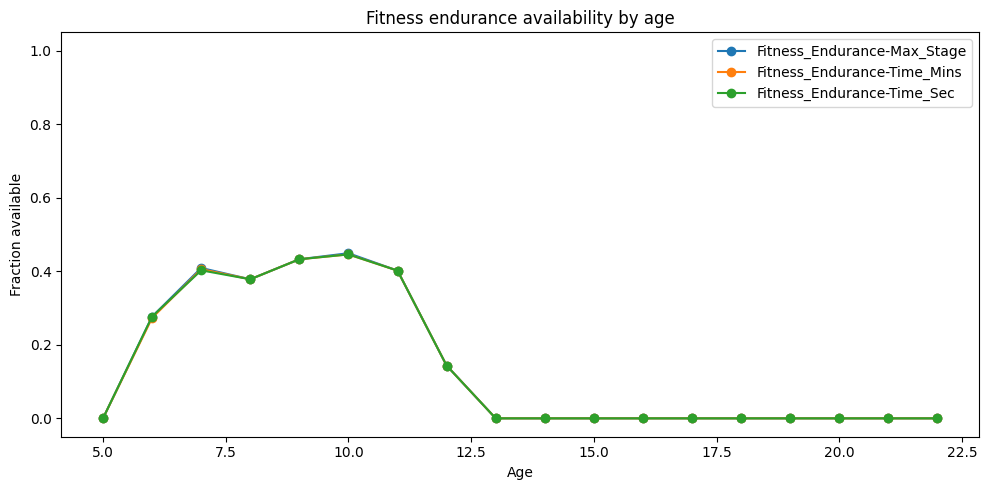

,Fitness_Endurance-Max_Stage,Fitness_Endurance-Time_Mins,Fitness_Endurance-Time_Sec
Basic_Demos-Age,,,
5,0.000,0.000,0.000
6,0.277,0.273,0.277
7,0.409,0.406,0.403
8,0.378,0.378,0.378
9,0.433,0.433,0.433
10,0.449,0.446,0.446
11,0.402,0.402,0.402
12,0.144,0.144,0.144
13,0.000,0.000,0.000


In [13]:
fitness_endurance_numeric = [
    c for c in FITNESS_ENDURANCE
    if c in NUMERIC_COLS
]

fitness_endurance_availability = plot_availability_by_age(
    labeled,
    fitness_endurance_numeric,
    "Fitness endurance availability by age",
)

display(fitness_endurance_availability.round(3))


### Interpretation

После контроля возраста `Fitness_Endurance-Max_Stage` и `Fitness_Endurance-Time_Mins` сохраняют небольшую отрицательную association с `sii` (порядка −0.09).

Однако тест доступен лишь для части участников. Поэтому этот блок может быть полезен, но его вклад нужно оценивать вместе с missingness indicator и только через cross-validation.


## 8. FitnessGram Child

FitnessGram Child содержит raw performance measures и соответствующие fitness-zone categories.

Raw performance сильно зависит от возраста, поэтому сравниваем raw и age-adjusted associations.


In [14]:
FGC = instrument_features.get("FitnessGram Child", [])

fgc_numeric = numeric_association_table(labeled, FGC)
fgc_categorical = categorical_association_table(labeled, FGC)

display(fgc_numeric.round(4))
display(fgc_categorical.round(4))


,feature,n,raw_rho,raw_p,partial_rho_age,partial_p_age,abs_partial_rho
0,FGC-FGC_GSND,872,0.1962,0.0000,0.0880,0.0094,0.0880
1,FGC-FGC_GSD,871,0.1907,0.0000,0.0748,0.0273,0.0748
2,FGC-FGC_CU,1919,0.2825,0.0000,0.0711,0.0018,0.0711
3,FGC-FGC_PU,1909,0.1815,0.0000,0.0478,0.0367,0.0478
4,FGC-FGC_TL,1919,0.1177,0.0000,0.0190,0.4058,0.0190
5,FGC-FGC_SRL,1911,-0.0626,0.0062,-0.0076,0.7411,0.0076
6,FGC-FGC_SRR,1913,-0.0543,0.0174,0.0022,0.9242,0.0022


,feature,n_categories_including_missing,missing_%,cramers_v
0,FGC-FGC_GSND_Zone,4,68.4211,0.1445
1,FGC-FGC_GSD_Zone,4,68.4211,0.1437
2,FGC-FGC_SRL_Zone,3,31.3962,0.0663
3,FGC-Season,5,3.2529,0.0482
4,FGC-FGC_PU_Zone,3,31.4693,0.0450
5,FGC-FGC_SRR_Zone,3,31.3231,0.0426
6,FGC-FGC_CU_Zone,3,31.1404,0.0315
7,FGC-FGC_TL_Zone,3,31.1038,0.0271


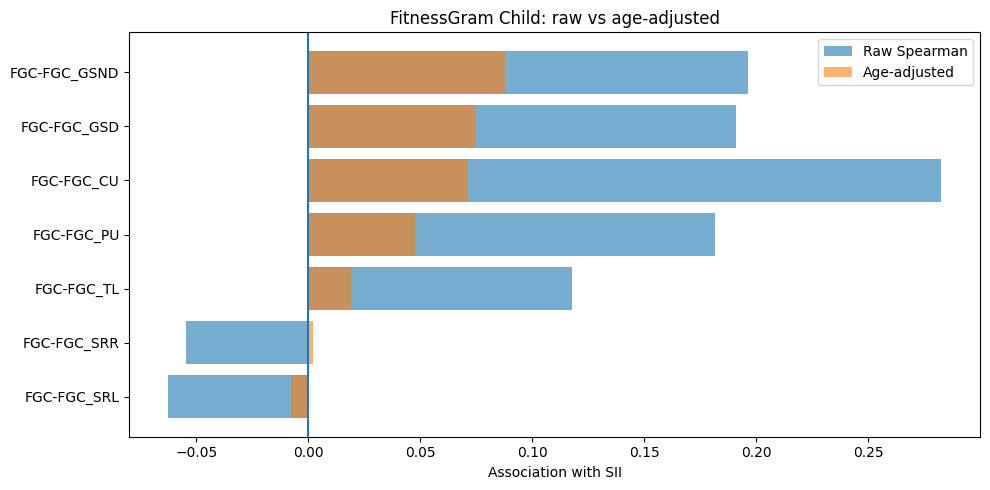

In [15]:
fgc_plot = (
    fgc_numeric
    .dropna(subset=["partial_rho_age"])
    .sort_values("partial_rho_age")
)

plt.figure(figsize=(10, 5))
plt.barh(
    fgc_plot["feature"],
    fgc_plot["raw_rho"],
    alpha=0.6,
    label="Raw Spearman",
)
plt.barh(
    fgc_plot["feature"],
    fgc_plot["partial_rho_age"],
    alpha=0.6,
    label="Age-adjusted",
)
plt.axvline(0)
plt.xlabel("Association with SII")
plt.ylabel("")
plt.title("FitnessGram Child: raw vs age-adjusted")
plt.legend()
plt.tight_layout()
plt.show()


### Interpretation

Raw curl-up, push-up и grip-strength scores показывают positive association с `sii`, но большая часть этого эффекта уменьшается после age adjustment.

Самые заметные age-adjusted associations остаются у grip strength и curl-ups, но они всё равно невелики (`|rho| < 0.1`).

Zone variables также показывают некоторую categorical association, однако часть её может возникать из-за структурного missingness.


## 9. Bio-electric Impedance Analysis (BIA)

BIA — самый большой физический блок: body composition, water compartments, muscle mass, BMR и т.д.

В `04_tabular_feature_eda.ipynb` здесь также были обнаружены наиболее выраженные extreme values, поэтому интерпретация должна учитывать как confounding, так и data quality.


In [16]:
BIA = instrument_features.get(
    "Bio-electric Impedance Analysis",
    [],
)

bia_numeric = numeric_association_table(labeled, BIA)
bia_categorical = categorical_association_table(labeled, BIA)

display(bia_numeric.round(4))
display(bia_categorical.round(4))


,feature,n,raw_rho,raw_p,partial_rho_age,partial_p_age,abs_partial_rho
0,BIA-BIA_ICW,1813,0.3597,0.0,0.0890,0.0001,0.0890
1,BIA-BIA_LDM,1813,0.3667,0.0,0.0741,0.0016,0.0741
2,BIA-BIA_SMM,1813,0.3549,0.0,0.0656,0.0052,0.0656
3,BIA-BIA_BMR,1813,0.3673,0.0,0.0601,0.0105,0.0601
4,BIA-BIA_FFM,1813,0.3673,0.0,0.0601,0.0105,0.0601
5,BIA-BIA_LST,1813,0.3600,0.0,0.0508,0.0305,0.0508
6,BIA-BIA_DEE,1813,0.3061,0.0,0.0506,0.0312,0.0506
7,BIA-BIA_BMI,1813,0.2391,0.0,0.0402,0.0870,0.0402
8,BIA-BIA_TBW,1813,0.3483,0.0,0.0400,0.0887,0.0400
9,BIA-BIA_Fat,1813,0.2759,0.0,0.0364,0.1213,0.0364


,feature,n_categories_including_missing,missing_%,cramers_v
0,BIA-BIA_Frame_num,4,33.7354,0.0812
1,BIA-BIA_Activity_Level_num,6,33.7354,0.0122
2,BIA-Season,5,32.6023,0.0000


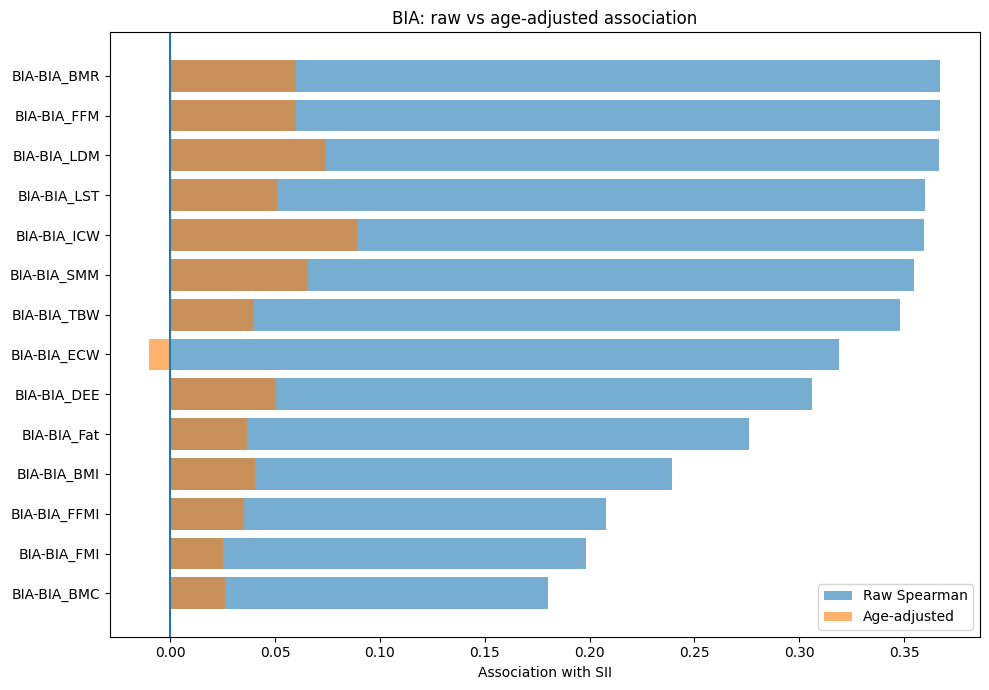

In [17]:
bia_compare = (
    bia_numeric[
        ["feature", "raw_rho", "partial_rho_age"]
    ]
    .dropna()
    .sort_values("raw_rho")
)

plt.figure(figsize=(10, 7))
plt.barh(
    bia_compare["feature"],
    bia_compare["raw_rho"],
    alpha=0.6,
    label="Raw Spearman",
)
plt.barh(
    bia_compare["feature"],
    bia_compare["partial_rho_age"],
    alpha=0.6,
    label="Age-adjusted",
)
plt.axvline(0)
plt.xlabel("Association with SII")
plt.ylabel("")
plt.title("BIA: raw vs age-adjusted association")
plt.legend()
plt.tight_layout()
plt.show()


### Within-BIA redundancy

Многие BIA measurements являются производными или физиологически тесно связанными величинами. Проверяем Spearman correlations внутри блока, чтобы увидеть redundancy.


In [18]:
bia_numeric_cols = [
    c for c in BIA
    if c in NUMERIC_COLS
]

bia_corr = (
    labeled[bia_numeric_cols]
    .corr(method="spearman")
)

pairs = []

for i, col_a in enumerate(bia_corr.columns):
    for j, col_b in enumerate(bia_corr.columns):
        if j <= i:
            continue

        rho = bia_corr.loc[col_a, col_b]

        pairs.append({
            "feature_1": col_a,
            "feature_2": col_b,
            "rho": rho,
            "abs_rho": abs(rho),
        })

bia_redundancy = (
    pd.DataFrame(pairs)
    .sort_values("abs_rho", ascending=False)
    .reset_index(drop=True)
)

display(bia_redundancy.head(20).round(4))


,feature_1,feature_2,rho,abs_rho
0,BIA-BIA_BMR,BIA-BIA_FFM,1.0000,1.0000
1,BIA-BIA_BMR,BIA-BIA_LST,0.9926,0.9926
2,BIA-BIA_FFM,BIA-BIA_LST,0.9926,0.9926
3,BIA-BIA_FFM,BIA-BIA_TBW,0.9840,0.9840
4,BIA-BIA_BMR,BIA-BIA_TBW,0.9840,0.9840
5,BIA-BIA_LST,BIA-BIA_TBW,0.9804,0.9804
6,BIA-BIA_ECW,BIA-BIA_TBW,0.9720,0.9720
7,BIA-BIA_ICW,BIA-BIA_TBW,0.9616,0.9616
8,BIA-BIA_FMI,BIA-BIA_Fat,0.9616,0.9616
9,BIA-BIA_ECW,BIA-BIA_FFM,0.9548,0.9548


### Interpretation

BIA показывает один из самых ярких примеров confounding:

- raw correlations многих body-composition variables с `sii` находятся около `0.3–0.37`;
- после контроля возраста большинство падают примерно до `0.04–0.09`.

Дополнительно внутри BIA присутствует высокая redundancy между связанными body-composition variables.

Поэтому BIA не стоит воспринимать как большой набор независимых сильных predictors. Для моделирования важнее корректная обработка extreme values, missingness и multicollinearity/redundancy.


## 10. Physical Activity Questionnaire: PAQ-C and PAQ-A

PAQ-C и PAQ-A нельзя объединять как два обычных взаимозаменяемых признака:

- PAQ-C предназначен для children;
- PAQ-A — для adolescents.

Поэтому их missingness структурно зависит от возраста.


In [19]:
PAQ_C = instrument_features.get(
    "Physical Activity Questionnaire (Children)",
    [],
)

PAQ_A = instrument_features.get(
    "Physical Activity Questionnaire (Adolescents)",
    [],
)

PAQ_TOTALS = [
    c for c in PAQ_C + PAQ_A
    if c.endswith("_Total")
]

display(
    numeric_association_table(
        labeled,
        PAQ_TOTALS,
    ).round(4)
)


,feature,n,raw_rho,raw_p,partial_rho_age,partial_p_age,abs_partial_rho
0,PAQ_A-PAQ_A_Total,363,-0.0616,0.2419,-0.0494,0.3479,0.0494
1,PAQ_C-PAQ_C_Total,1440,0.0005,0.9859,0.0083,0.7533,0.0083


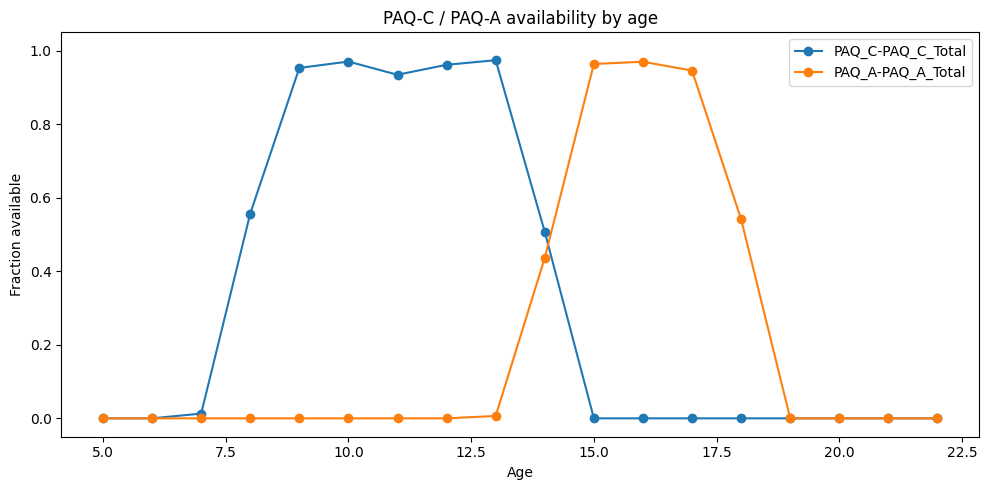

,PAQ_C-PAQ_C_Total,PAQ_A-PAQ_A_Total
Basic_Demos-Age,,
5,0.000,0.000
6,0.000,0.000
7,0.013,0.000
8,0.557,0.000
9,0.953,0.000
10,0.970,0.000
11,0.935,0.000
12,0.962,0.000
13,0.974,0.006


In [20]:
paq_availability = plot_availability_by_age(
    labeled,
    PAQ_TOTALS,
    "PAQ-C / PAQ-A availability by age",
)

display(paq_availability.round(3))


### Interpretation

В текущем tabular dataset neither PAQ-C nor PAQ-A показывает заметную direct ordinal association с `sii`.

При этом availability явно разделена по возрасту, поэтому обычная global median imputation для этих двух колонок плохо отражает структуру данных.

В preprocessing разумнее сохранить отдельные PAQ-C / PAQ-A признаки и учитывать age-dependent missingness.


## 11. Sleep Disturbance Scale (SDS)

SDS содержит Raw Score и T-Score.

В общем feature-level EDA этот блок выделялся наиболее устойчивой age-adjusted association с `sii`.


,feature,n,raw_rho,raw_p,partial_rho_age,partial_p_age,abs_partial_rho
0,SDS-SDS_Total_Raw,2527,0.2307,0.0,0.2385,0.0,0.2385
1,SDS-SDS_Total_T,2525,0.2302,0.0,0.2383,0.0,0.2383


C:\Users\HP\AppData\Local\Temp\ipykernel_10576\1694861711.py:153: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


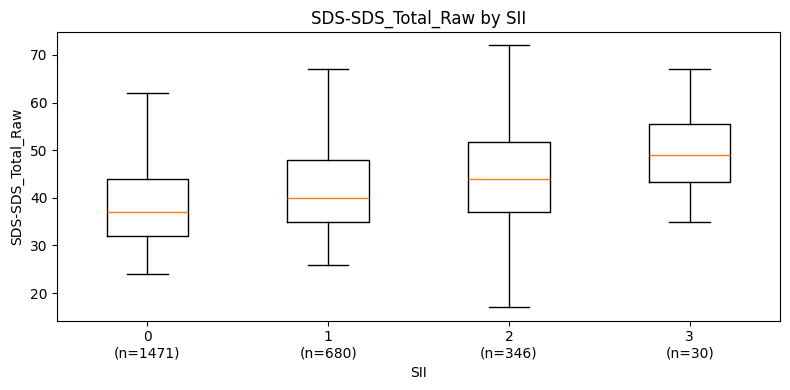

C:\Users\HP\AppData\Local\Temp\ipykernel_10576\1694861711.py:153: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


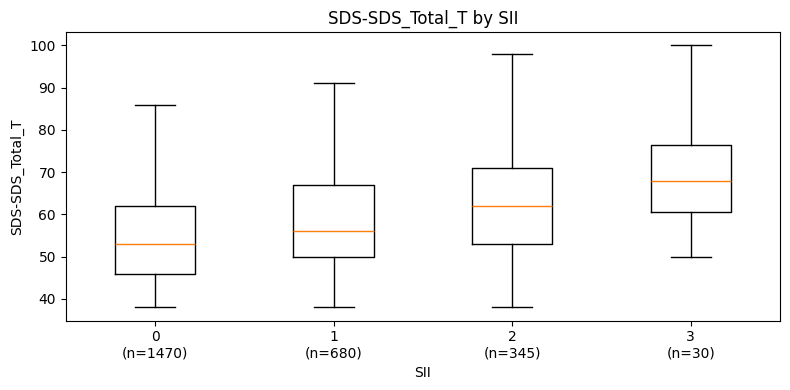

In [21]:
SDS = instrument_features.get(
    "Sleep Disturbance Scale",
    [],
)

sds_assoc = numeric_association_table(labeled, SDS)

display(sds_assoc.round(4))

for feature in [
    "SDS-SDS_Total_Raw",
    "SDS-SDS_Total_T",
]:
    if feature in labeled.columns:
        plot_numeric_by_sii(labeled, feature)


### Raw vs T-score redundancy

Проверяем, насколько два summary scores фактически дублируют друг друга.


In [22]:
sds_pair = labeled[
    ["SDS-SDS_Total_Raw", "SDS-SDS_Total_T"]
].dropna()

sds_raw_t_rho = spearmanr(
    sds_pair["SDS-SDS_Total_Raw"],
    sds_pair["SDS-SDS_Total_T"],
).statistic

print(
    "Spearman Raw vs T-score:",
    round(sds_raw_t_rho, 4),
)


Spearman Raw vs T-score: 1.0


### Interpretation

SDS — наиболее заметный non-demographic block в tabular EDA:

- raw association с `sii` около `0.23`;
- после контроля возраста она не исчезает и остаётся около `0.24`.

При этом Raw и T scores очень тесно связаны, поэтому обе колонки могут быть избыточны в некоторых моделях.

Этот блок стоит обязательно сохранить в baseline и отдельно проверить, нужен ли одновременно Raw и T score.


## 12. Internet Use

`PreInt_EduHx-computerinternet_hoursday` — категориальная оценка количества часов использования компьютера/интернета в день.

Это один из немногих признаков, содержательно близких к target, но он не является частью PCIAT и присутствует в test.


In [23]:
INTERNET_USE = instrument_features.get(
    "Internet Use",
    [],
)

internet_assoc = categorical_association_table(
    labeled,
    INTERNET_USE,
)

display(internet_assoc.round(4))


,feature,n_categories_including_missing,missing_%,cramers_v
0,PreInt_EduHx-computerinternet_hoursday,5,2.9971,0.2041
1,PreInt_EduHx-Season,5,0.6213,0.0000


In [24]:
HOURS_COL = "PreInt_EduHx-computerinternet_hoursday"

internet_hours_by_sii = pd.crosstab(
    labeled[HOURS_COL],
    labeled[TARGET],
    normalize="index",
) * 100

display(internet_hours_by_sii.round(2))


sii,0.0,1.0,2.0,3.0
PreInt_EduHx-computerinternet_hoursday,,,,
0.0,73.82,19.64,6.15,0.39
1.0,47.35,36.18,15.88,0.59
2.0,47.19,32.53,18.75,1.53
3.0,28.63,33.59,32.06,5.73


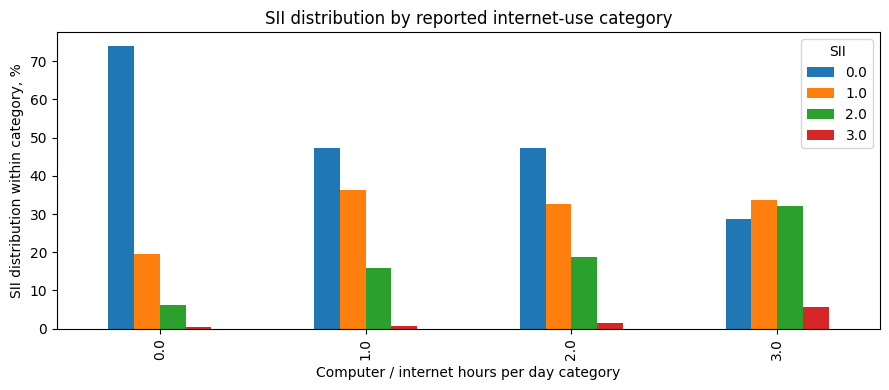

In [25]:
internet_hours_by_sii.plot(
    kind="bar",
    figsize=(9, 4),
)

plt.xlabel("Computer / internet hours per day category")
plt.ylabel("SII distribution within category, %")
plt.title("SII distribution by reported internet-use category")
plt.legend(title="SII")
plt.tight_layout()
plt.show()


### Interpretation

`PreInt_EduHx-computerinternet_hoursday` показывает одну из наиболее заметных categorical associations с `sii` (Cramér's V около `0.20`).

В отличие от многих physical/BIA features, здесь связь содержательно напрямую относится к internet-use behavior.

Этот признак является очевидным кандидатом для baseline model, при этом его нужно сохранять как categorical/ordinal variable, а не автоматически трактовать как произвольное continuous число.


## 13. Cross-instrument summary

Собираем единый instrument-level summary:

- coverage;
- strongest raw numeric association;
- strongest age-adjusted numeric association;
- strongest categorical association.


In [26]:
summary_rows = []

for instrument, cols in instrument_features.items():
    num_table = numeric_association_table(labeled, cols)
    cat_table = categorical_association_table(labeled, cols)

    strongest_raw_feature = None
    strongest_raw_rho = np.nan
    strongest_partial_feature = None
    strongest_partial_rho = np.nan
    strongest_cat_feature = None
    strongest_cat_v = np.nan

    if not num_table.empty:
        raw_idx = num_table["raw_rho"].abs().idxmax()
        strongest_raw_feature = num_table.loc[raw_idx, "feature"]
        strongest_raw_rho = num_table.loc[raw_idx, "raw_rho"]

        partial_valid = num_table.dropna(
            subset=["partial_rho_age"]
        )

        if not partial_valid.empty:
            partial_idx = (
                partial_valid["partial_rho_age"]
                .abs()
                .idxmax()
            )
            strongest_partial_feature = (
                partial_valid.loc[partial_idx, "feature"]
            )
            strongest_partial_rho = (
                partial_valid.loc[
                    partial_idx,
                    "partial_rho_age",
                ]
            )

    if not cat_table.empty:
        cat_idx = cat_table["cramers_v"].idxmax()
        strongest_cat_feature = cat_table.loc[cat_idx, "feature"]
        strongest_cat_v = cat_table.loc[cat_idx, "cramers_v"]

    coverage_row = instrument_coverage.loc[
        instrument_coverage["instrument"].eq(instrument)
    ].iloc[0]

    summary_rows.append({
        "instrument": instrument,
        "n_features": len(cols),
        "participants_any_data_%": (
            coverage_row["participants_any_data_%"]
        ),
        "strongest_raw_numeric": strongest_raw_feature,
        "raw_rho": strongest_raw_rho,
        "strongest_age_adjusted_numeric": (
            strongest_partial_feature
        ),
        "partial_rho_age": strongest_partial_rho,
        "strongest_categorical": strongest_cat_feature,
        "cramers_v": strongest_cat_v,
    })

instrument_summary = (
    pd.DataFrame(summary_rows)
    .sort_values(
        "partial_rho_age",
        key=lambda x: x.abs(),
        ascending=False,
        na_position="last",
    )
    .reset_index(drop=True)
)

display(instrument_summary.round(4))


,instrument,n_features,participants_any_data_%,strongest_raw_numeric,raw_rho,strongest_age_adjusted_numeric,partial_rho_age,strongest_categorical,cramers_v
0,Sleep Disturbance Scale,3,66.1111,SDS-SDS_Total_Raw,0.2307,SDS-SDS_Total_Raw,0.2385,SDS-Season,0.0113
1,FitnessGram Vitals and Treadmill,4,33.0303,Fitness_Endurance-Max_Stage,-0.0785,Fitness_Endurance-Max_Stage,-0.0948,Fitness_Endurance-Season,0.0803
2,Bio-electric Impedance Analysis,17,54.1667,BIA-BIA_BMR,0.3673,BIA-BIA_ICW,0.0890,BIA-BIA_Frame_num,0.0812
3,FitnessGram Child,15,84.4949,FGC-FGC_CU,0.2825,FGC-FGC_GSND,0.0880,FGC-FGC_GSND_Zone,0.1445
4,Physical Measures,8,83.5859,Physical-Height,0.3775,Physical-Height,0.0842,Physical-Season,0.0000
5,Children's Global Assessment Scale,2,64.5202,CGAS-CGAS_Score,-0.0730,CGAS-CGAS_Score,-0.0762,CGAS-Season,0.0000
6,Physical Activity Questionnaire (Adolescents),2,11.9949,PAQ_A-PAQ_A_Total,-0.0616,PAQ_A-PAQ_A_Total,-0.0494,PAQ_A-Season,0.1284
7,Physical Activity Questionnaire (Children),2,43.4596,PAQ_C-PAQ_C_Total,0.0005,PAQ_C-PAQ_C_Total,0.0083,PAQ_C-Season,0.0711
8,Demographics,3,100.0000,Basic_Demos-Age,0.3787,None,NaN,Basic_Demos-Sex,0.0948
9,Internet Use,2,89.3939,None,NaN,None,NaN,PreInt_EduHx-computerinternet_hoursday,0.2041


## 14. Main findings to carry forward

1. **Demographics is structurally important.** Age is one of the strongest univariate correlates of `sii` and acts as a major confounder for physical, fitness and body-composition variables.

2. **Physical Measures and BIA look much weaker after age adjustment.** Their relatively large raw correlations are largely explained by growth and age-related body changes rather than a strong independent relationship with `sii`.

3. **BIA additionally contains substantial redundancy and data-quality issues.** Many body-composition variables are strongly intercorrelated, while the previous EDA identified several extreme values. This block should not be treated as a set of independent high-value predictors.

4. **Fitness blocks retain only weak age-adjusted associations.** Some grip-strength, curl-up and endurance measures remain mildly associated with `sii`, but coverage is incomplete and the effects are small.

5. **CGAS has a weak negative relationship with `sii`.** The association remains after controlling for age but is small, so CGAS is potentially useful as supporting rather than dominant information.

6. **PAQ-C and PAQ-A have structural age-dependent missingness.** Their direct associations with `sii` are weak, and the two instruments should not be merged through naive global imputation.

7. **SDS is the strongest non-demographic numeric block.** Both `SDS-SDS_Total_Raw` and `SDS-SDS_Total_T` retain an age-adjusted association with `sii` of approximately `0.24`. However, Raw and T scores are highly redundant, so using both may be unnecessary.

8. **Reported computer/internet usage is one of the strongest categorical signals.** `PreInt_EduHx-computerinternet_hoursday` has Cramér's V of roughly `0.20` with `sii` and is directly relevant to the behavioral nature of the target.

9. **Missingness is instrument-specific rather than random.** Coverage differs substantially across instruments and frequently depends on age or study design. Missing indicators may therefore be useful features, but their interpretation requires caution.

10. For baseline modeling, the most promising tabular blocks to preserve explicitly are:
    - Demographics;
    - SDS;
    - Internet Use;
    - CGAS;
    - selected Physical / Fitness features.

    BIA should be included only with robust cleaning and careful validation of whether its large feature count adds predictive value beyond age and simpler physical measures.
